In [42]:
!pip install -q bitsandbytes accelerate
!pip install -U bitsandbytes
!pip install -q git+https://github.com/huggingface/transformers.git@main
!pip install -q git+https://github.com/huggingface/peft.git@main

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [43]:
import pandas as pd
from google.colab import files
import os
filename = "Q2_20230202_majority 1.csv"

if not os.path.exists(filename):
  print(f"'{filename}' not found. Please upload the file.")
  uploaded = files.upload()
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("Q2_20230202_majority 1.csv")
df.sample(5)

,tweet_id,created_at,tweet,label_majority,month
4164,1.359191e+18,2021-02-09 17:22:28+00:00,"vaccines could drive the evolution of more covid-19 mutants ( coronaviruses can make vaccines less the same time, vaccines can contribute t.....add your highlights:. #health",against,21-Feb
3157,1.392549e+18,2021-05-12 18:34:24+00:00,the va is offering covid shots for kids 12 and up today at usf yuengling center. it’s a drive up site open to the community (not just veterans). you have to present the child’s birth certificate or student id and sign a consent form.,in-favor,21-May
580,1.432141e+18,2021-08-30 00:41:47+00:00,„these shots weaken people’s immune system“ .watch where you go…..#novaccinemandates .#novaccinepassportanywhere,against,21-Aug
4494,1.353374e+18,2021-01-24 16:07:32+00:00,"vaccine rollout on schedule despite pfizer shortages, treasurer says",in-favor,21-Jan
920,1.439228e+18,2021-09-18 14:02:12+00:00,"slovenwoia (currently holds presidency of european union council).protests against one of the the worst covid measures in eu: no food buying in stores, no hairdresser, no fuel, no doctor's visit without rapid or pcr test (costs 10 €, lasts 48hours) or vaccine passport (for free)",against,21-Sep


In [44]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import zipfile
import os

model_dir = "finetuned-flan-t5-vaccine_phase3_mixed (5)"
zip_path = "/content/" + model_dir + ".zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(model_dir)

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(model_dir)

In [45]:
import torch
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [46]:
def format_prompt(tweet):

    examples = (
        f'Here are a few examples:'
        f'Tweet: "Vaccines saved my life" Stance: "in-favor"\n'
        f'Tweet: "Still deciding on those shots..." Stance: "neutral-or-unclear"\n'
        f'Tweet: "This vaccine is poison." Stance: "Against"\n'
        f'Now analyze:\n'
    )
    prompt = (
        f'What is the stance of the **author** of the following tweet toward COVID-19 vaccines?\n'
        f'Classify the stance as exactly one of: in-favor, against, neutral-or-unclear. If the stance is unclear or mixed or if the tweet is off-topic, choose "neutral-or-unclear".\n'
        f'{examples}'
        f'Tweet: "{tweet}"\n'
        f'Respond with one exactly of the following options: "in-favor", "against", "neutral-or-unclear".'
    )

    return prompt


def normalize(text):
    return text.strip().lower().replace("-", "").replace("_", "").replace(" ", "")


def predict_stance(tweet, tokenizer, model):
    prompt = format_prompt(tweet)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=10)
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return prediction

print("functions loaded, trying samples\n\n")

sample_tweets = [
    "I'm really happy I got my COVID-19 vaccine today!",
    "The government forcing vaccines is just wrong.",
    "I heard mixed things about the vaccine, still unsure if I should take it.",
    "trumps operation warp speed"
]

for tweet in sample_tweets:
    prediction = predict_stance(tweet, tokenizer, model)
    print(f"\nTweet: {tweet}")
    print(f"Predicted Sentiment: {prediction}")

functions loaded, trying samples



Tweet: I'm really happy I got my COVID-19 vaccine today!
Predicted Sentiment: in-favor

Tweet: The government forcing vaccines is just wrong.
Predicted Sentiment: against

Tweet: I heard mixed things about the vaccine, still unsure if I should take it.
Predicted Sentiment: neutral-or-unclear

Tweet: trumps operation warp speed
Predicted Sentiment: neutral-or-unclear


In [ ]:
preds = []
labels = []
wrong = []

print("Generating predictions...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    tweet = row['tweet']
    label = row['label_majority']

    prediction = predict_stance(tweet, tokenizer, model)

    if prediction != label:
        wrong.append({
            "tweet": tweet,
            "label_majority": label,
            "prev_pred": prediction
        })
    preds.append(prediction)
    labels.append(label)

df['predicted'] = preds

In [47]:
# preds = []
# labels = []
# wrong = []

# # Sample 10% of dataset for evaluation
# df_test1, _ = train_test_split(df, test_size=0.9, stratify=df['label_majority'], random_state=42)

# print("Generating predictions...")
# for _, row in tqdm(df_test1.iterrows(), total=len(df_test1)):
#     tweet = row['tweet']
#     label = row['label_majority']

#     prediction = predict_stance(tweet, tokenizer, model)

#     if prediction != label:
#         wrong.append({
#             "tweet": tweet,
#             "label_majority": label,
#             "prev_pred": prediction
#         })
#     preds.append(prediction)
#     labels.append(label)

# df_test1['predicted'] = preds

Generating predictions...


100%|██████████| 115/115 [10:02<00:00,  5.24s/it]


In [48]:
# Overall Accuracy
correct = sum(p == l for p, l in zip(preds, labels))
accuracies = [["Total Validation", f"{correct / len(labels):.3f}"]]

# Per-label Accuracy
label_list = ["in-favor", "against", "neutral-or-unclear"]
for label in label_list:
    total_label = labels.count(label)
    if total_label > 0:
        correct_label = sum(p == l for p, l in zip(preds, labels) if l == label)
        accuracy = correct_label / total_label
        accuracies.append([label, f"{accuracy:.3f}"])
    else:
        accuracies.append([label, "N/A"])

acc_df = pd.DataFrame(accuracies, columns=["Label", "Accuracy"])
print(acc_df)

                Label Accuracy
0    Total Validation    0.609
1            in-favor    0.569
2             against    0.806
3  neutral-or-unclear    0.381


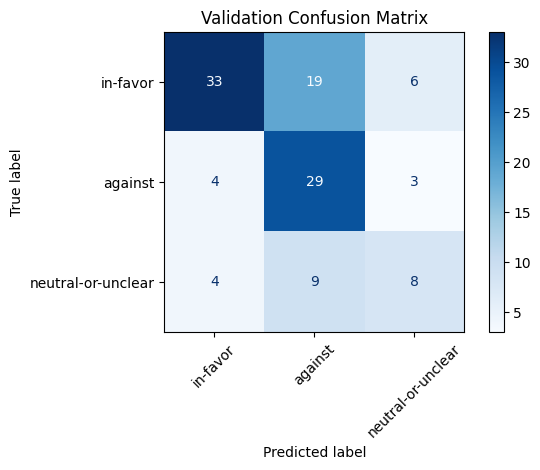

In [49]:
# Confusion Matrix
cm = confusion_matrix(labels, preds, labels=label_list)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_list)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [50]:
df_test1["correct?"] = df_test1["label_majority"] == df_test1["predicted"]

In [51]:
df_test1.head()

,tweet_id,created_at,tweet,label_majority,month,predicted,correct?
3939,1.371599e+18,2021-03-15 23:06:59+00:00,"people who won’t wear masks bc they say they have a “medical condition” that prevents them from wearing them, are the same folk who refuse to get the vaccine even though said “medical condition” would make them eligible &amp; put them at extra covid risk. in short, they’re just liars",in-favor,21-Mar,against,False
67,1.422601e+18,2021-08-03 16:49:48+00:00,3 deaths have been linked to getting vaccinated and 4.23 million deaths have been linked to not getting vaccinated. it’s so hard to decide.,in-favor,21-Aug,in-favor,True
5633,1.527333e+18,2022-05-19 16:59:56+00:00,"the flight restrictions are partially a social engineering experiment/program fundamentally altering the nature of our social fabric, as well as being more about creating conditions that will cause people to comply to the vaccine program rather than preventing spread of the virus",against,22-May,against,True
4201,1.360559e+18,2021-02-13 11:57:09+00:00,601 of those were reported in america where 50million doses have been given meaning 0.001% of those vaccinated,in-favor,21-Feb,against,False
4011,1.374411e+18,2021-03-23 17:19:46+00:00,"how can you still think the vaccine will give you your life back?..remember last summer, when there was no vaccine, but people could go on holiday? and this summer, when they can't, despite the vaccine?..please wake up.",against,21-Mar,against,True


In [52]:
df_test1[df_test1["correct?"] == False]

,tweet_id,created_at,tweet,label_majority,month,predicted,correct?
3939,1.371599e+18,2021-03-15 23:06:59+00:00,"people who won’t wear masks bc they say they have a “medical condition” that prevents them from wearing them, are the same folk who refuse to get the vaccine even though said “medical condition” would make them eligible &amp; put them at extra covid risk. in short, they’re just liars",in-favor,21-Mar,against,False
4201,1.360559e+18,2021-02-13 11:57:09+00:00,601 of those were reported in america where 50million doses have been given meaning 0.001% of those vaccinated,in-favor,21-Feb,against,False
4909,1.479913e+18,2022-01-08 20:27:05+00:00,"good. i’ll stop being a “non vaxxer” as soon as the drug companies waive their lawsuit immunity, and release all their safety test results. since their vaccines are so safe, that shouldn’t be a problem, right?",against,22-Jan,in-favor,False
2984,1.408430e+18,2021-06-25 14:19:34+00:00,covid vaccines do not cause infertility: health ministry #covidvaccine #infertility #fakenews,in-favor,21-Jun,neutral-or-unclear,False
2993,1.408905e+18,2021-06-26 21:46:51+00:00,cdc did not change the pcr for vaxxed people.,neutral-or-unclear,21-Jun,against,False
5560,1.521291e+18,2022-05-03 00:51:14+00:00,"dear tucker carlson. if you are successfully vaxxed and boosted to protect you against hospitalization or death from covid, why do you tell your viewers that the vaccine is bad?",in-favor,22-May,against,False
4786,1.344189e+18,2020-12-30 07:50:41+00:00,"y’all screaming “my body, my choice” about covid vaccines should realize that we’re spiraling into “my er, my choice” about who receives treatment.",in-favor,20-Dec,neutral-or-unclear,False
2811,1.401248e+18,2021-06-05 18:41:33+00:00,"cal/osha, the board that oversees workplace safety, is ordering all californians to remain masked at work until at least october, unless everyone around them is vaccinated. -",in-favor,21-Jun,against,False
219,1.425039e+18,2021-08-10 10:17:35+00:00,anyone home? #wakeup people!.#covid19 #covidvaccine .#leaveourkidsalone .#novaccinepassports .#southafrica,against,21-Aug,in-favor,False
243,1.425492e+18,2021-08-11 16:20:01+00:00,heard this morning by mccallum “immunities do not have a lobbyist in washington immunities aren’t profitable”.i thought that was quite astute. #covidvaccine,neutral-or-unclear,21-Aug,in-favor,False
